First 5 rows:


,ID,Experience_Years,Age,Gender,Salary
0,1,5,28,Female,250000
1,2,1,21,Male,50000
2,3,3,23,Female,170000
3,4,2,22,Male,25000
4,5,1,17,Male,10000



Dataset Shape:
(35, 5)

Column Names:
['ID', 'Experience_Years', 'Age', 'Gender', 'Salary']

Missing Values:
ID                  0
Experience_Years    0
Age                 0
Gender              0
Salary              0
dtype: int64

Dataset after cleaning:
(35, 5)

Median Salary:
250000.0

Target Distribution:
Salary_Class
1    18
0    17
Name: count, dtype: int64

Salary Classification:
0 = Low Salary
1 = High Salary

Features after encoding:


,ID,Experience_Years,Age,Gender_Male
0,1,5,28,False
1,2,1,21,True
2,3,3,23,False
3,4,2,22,True
4,5,1,17,True



Training Data Shape:
(28, 4)

Testing Data Shape:
(7, 4)

MODEL COMPARISON


,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.571429,0.666667,0.5,0.571429
1,Decision Tree,0.857143,0.800000,1.0,0.888889
2,KNN,0.571429,0.666667,0.5,0.571429



NAIVE BAYES CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Low Salary       0.50      0.67      0.57         3
 High Salary       0.67      0.50      0.57         4

    accuracy                           0.57         7
   macro avg       0.58      0.58      0.57         7
weighted avg       0.60      0.57      0.57         7


DECISION TREE CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Low Salary       1.00      0.67      0.80         3
 High Salary       0.80      1.00      0.89         4

    accuracy                           0.86         7
   macro avg       0.90      0.83      0.84         7
weighted avg       0.89      0.86      0.85         7


KNN CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Low Salary       0.50      0.67      0.57         3
 High Salary       0.67      0.50      0.57         4

    accuracy                           0.57         7
   macro avg       0.58      

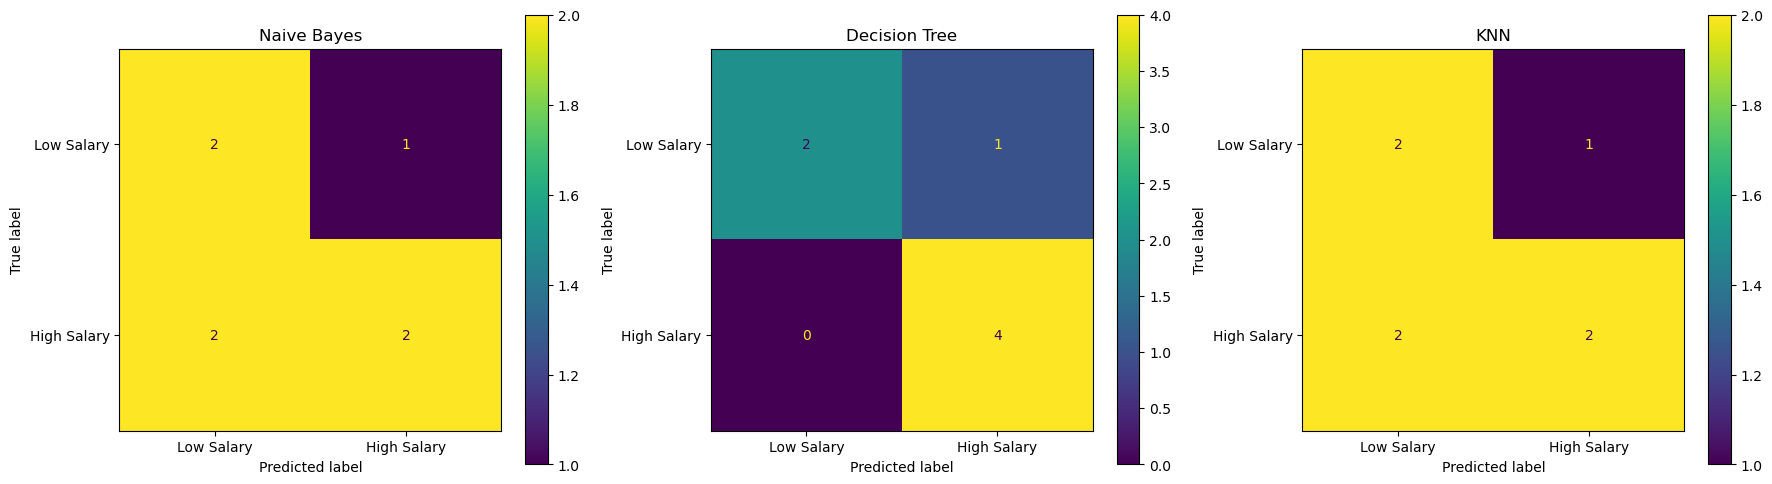


BEST PERFORMING ALGORITHM
Algorithm: Decision Tree
Accuracy: 85.71 %


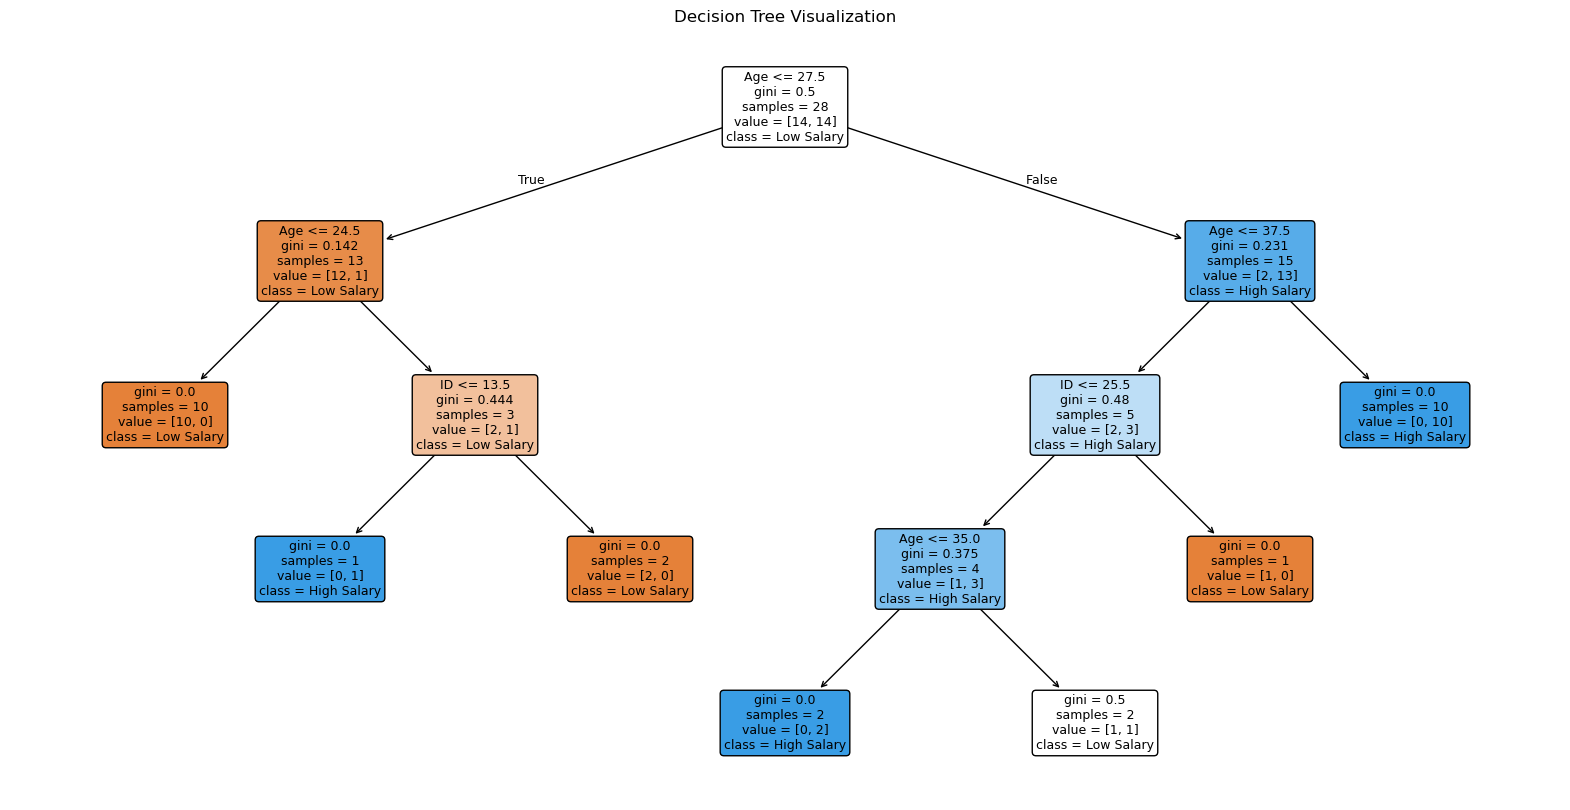

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================
# 1. LOAD DATASET
# ============================================

df = pd.read_csv("Employee_Salary_Dataset.csv")

print("First 5 rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================
# 2. CLEAN DATA
# ============================================

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

print("\nDataset after cleaning:")
print(df.shape)


# ============================================
# 3. CREATE TARGET COLUMN
# ============================================

salary_median = df["Salary"].median()

print("\nMedian Salary:")
print(salary_median)

# 0 = Low Salary
# 1 = High Salary

df["Salary_Class"] = np.where(
    df["Salary"] >= salary_median,
    1,
    0
)

print("\nTarget Distribution:")
print(df["Salary_Class"].value_counts())

print("\nSalary Classification:")
print("0 = Low Salary")
print("1 = High Salary")


# ============================================
# 4. SELECT FEATURES AND TARGET
# ============================================

X = df[
    [
        "ID",
        "Experience_Years",
        "Age",
        "Gender"
    ]
]

y = df["Salary_Class"]


# ============================================
# 5. CONVERT CATEGORICAL DATA
# ============================================

X = pd.get_dummies(
    X,
    columns=["Gender"],
    drop_first=True
)

print("\nFeatures after encoding:")
display(X.head())


# ============================================
# 6. TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)


# ============================================
# 7. FEATURE SCALING
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ============================================
# 8. NAIVE BAYES
# ============================================

nb_model = GaussianNB()

nb_model.fit(
    X_train_scaled,
    y_train
)

nb_prediction = nb_model.predict(
    X_test_scaled
)


# ============================================
# 9. DECISION TREE
# ============================================

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

dt_model.fit(
    X_train,
    y_train
)

dt_prediction = dt_model.predict(
    X_test
)


# ============================================
# 10. KNN
# ============================================

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)

knn_prediction = knn_model.predict(
    X_test_scaled
)


# ============================================
# 11. MODEL COMPARISON
# ============================================

models = {
    "Naive Bayes": nb_prediction,
    "Decision Tree": dt_prediction,
    "KNN": knn_prediction
}

results = []

for name, prediction in models.items():

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    precision = precision_score(
        y_test,
        prediction,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        prediction,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        prediction,
        zero_division=0
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])


results_df = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)


# ============================================
# 12. DISPLAY RESULTS
# ============================================

print("\n============================================")
print("MODEL COMPARISON")
print("============================================")

display(results_df)


# ============================================
# 13. CLASSIFICATION REPORTS
# ============================================

print("\n============================================")
print("NAIVE BAYES CLASSIFICATION REPORT")
print("============================================")

print(
    classification_report(
        y_test,
        nb_prediction,
        target_names=[
            "Low Salary",
            "High Salary"
        ],
        zero_division=0
    )
)


print("\n============================================")
print("DECISION TREE CLASSIFICATION REPORT")
print("============================================")

print(
    classification_report(
        y_test,
        dt_prediction,
        target_names=[
            "Low Salary",
            "High Salary"
        ],
        zero_division=0
    )
)


print("\n============================================")
print("KNN CLASSIFICATION REPORT")
print("============================================")

print(
    classification_report(
        y_test,
        knn_prediction,
        target_names=[
            "Low Salary",
            "High Salary"
        ],
        zero_division=0
    )
)


# ============================================
# 14. CONFUSION MATRICES
# ============================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)


# Naive Bayes
ConfusionMatrixDisplay(
    confusion_matrix(
        y_test,
        nb_prediction
    ),
    display_labels=[
        "Low Salary",
        "High Salary"
    ]
).plot(ax=axes[0])

axes[0].set_title("Naive Bayes")


# Decision Tree
ConfusionMatrixDisplay(
    confusion_matrix(
        y_test,
        dt_prediction
    ),
    display_labels=[
        "Low Salary",
        "High Salary"
    ]
).plot(ax=axes[1])

axes[1].set_title("Decision Tree")


# KNN
ConfusionMatrixDisplay(
    confusion_matrix(
        y_test,
        knn_prediction
    ),
    display_labels=[
        "Low Salary",
        "High Salary"
    ]
).plot(ax=axes[2])

axes[2].set_title("KNN")


plt.tight_layout()
plt.show()


# ============================================
# 15. FIND BEST ALGORITHM
# ============================================

best_algorithm = results_df.loc[
    results_df["Accuracy"].idxmax(),
    "Algorithm"
]

best_accuracy = results_df["Accuracy"].max()

print("\n============================================")
print("BEST PERFORMING ALGORITHM")
print("============================================")

print("Algorithm:", best_algorithm)

print(
    "Accuracy:",
    round(best_accuracy * 100, 2),
    "%"
)


# ============================================
# 16. DECISION TREE VISUALIZATION
# ============================================

plt.figure(
    figsize=(20, 10)
)

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=[
        "Low Salary",
        "High Salary"
    ],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title(
    "Decision Tree Visualization"
)

plt.show()